In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split


In [184]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using mps device


In [185]:
# Download latest version
path = kagglehub.dataset_download("venky73/spam-mails-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/ignacio/.cache/kagglehub/datasets/venky73/spam-mails-dataset/versions/1


In [186]:
# load the dataset

df = pd.read_csv(path + "/spam_ham_dataset.csv", encoding="latin-1")

# change type of label_num to int
df["label_num"] = df["label_num"].astype(int)

# add is_spam column
df["is_spam"] = df["label_num"] == 1

# drop others columns
df = df[["text", "is_spam"]]

df.head()

,text,is_spam
0,Subject: enron methanol ; meter # : 988291\r\n...,False
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",False
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",False
3,"Subject: photoshop , windows , office . cheap ...",True
4,Subject: re : indian springs\r\nthis deal is t...,False


We want to build a neural network that can classify mails as spam or not spam. we have the features text and label_num. we have a 2 possible classes: label_num = [0, 1]. 0 means that the email is not spam, 1 means spam

We will use the text feature to train our model. we will use the label_num as the target variable. we will split the dataset into training and testing sets. we will use 80% of the data for training and 20% for testing.


In [187]:
X = df["text"]
assert X.shape[0] != 0, "No data found in the 'text' column."
y = df["is_spam"]
assert y.shape[0] != 0, "No data found in the 'is_spam' column."
assert y.unique().tolist() == [0, 1], (
    "Unexpected labels found in 'is_spam' column. Expected 0 and 1 only."
)

print("Data loaded successfully. Number of samples:", X.shape[0])

Data loaded successfully. Number of samples: 5171


In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Train set size: 4136
Test set size: 1035


Number of components that explain 90% of the variance: 1


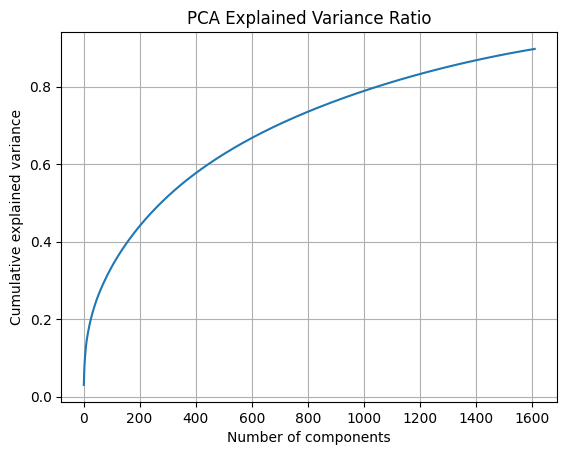

In [ ]:
# perform pca on text to find the 1000 most important latent features using torch
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

pca_model = PCA(n_components=1610)


# calculate pca on the text using tfidf vectorizer
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_train_pca = pca_model.fit_transform(X_train_tfidf.toarray())
X_test_tfidf = vectorizer.transform(X_test)
X_test_pca = pca_model.transform(X_test_tfidf.toarray())


# find the number of components that explain 90% of the variance
cumulative_explained_variance = pca_model.explained_variance_ratio_.cumsum()
n_components_90_variance = (cumulative_explained_variance >= 0.9).argmax() + 1
print(
    f"Number of components that explain 90% of the variance: {n_components_90_variance}"
)


plt.plot(
    range(1, len(pca_model.explained_variance_ratio_) + 1),
    pca_model.explained_variance_ratio_.cumsum(),
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Ratio")
plt.grid()
plt.show()


In [195]:
# generate embeddings for the text using tfidf vectorizer and pca
X_train_embeddings = torch.tensor(X_train_pca, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_test_embeddings = torch.tensor(X_test_pca, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

In [198]:
class SpamClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SpamClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x


input_size = X_train_embeddings.shape[1]
hidden_size = 128
output_size = 1

model = SpamClassifier(input_size, hidden_size, output_size).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 500

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_embeddings).squeeze()
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_embeddings).squeeze()
        test_loss = criterion(test_outputs, y_test_tensor)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}"
    )

with torch.no_grad():
    test_outputs = model(X_test_embeddings).squeeze()
    predicted = (test_outputs > 0.5).float()
    accuracy = (predicted == y_test_tensor).float().mean()
    print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

Epoch [1/500], Loss: 0.6990, Test Loss: 0.6976
Epoch [2/500], Loss: 0.6971, Test Loss: 0.6959
Epoch [3/500], Loss: 0.6952, Test Loss: 0.6942
Epoch [4/500], Loss: 0.6933, Test Loss: 0.6925
Epoch [5/500], Loss: 0.6914, Test Loss: 0.6907
Epoch [6/500], Loss: 0.6895, Test Loss: 0.6889
Epoch [7/500], Loss: 0.6875, Test Loss: 0.6871
Epoch [8/500], Loss: 0.6855, Test Loss: 0.6852
Epoch [9/500], Loss: 0.6835, Test Loss: 0.6833
Epoch [10/500], Loss: 0.6814, Test Loss: 0.6813
Epoch [11/500], Loss: 0.6793, Test Loss: 0.6793
Epoch [12/500], Loss: 0.6771, Test Loss: 0.6772
Epoch [13/500], Loss: 0.6748, Test Loss: 0.6750
Epoch [14/500], Loss: 0.6724, Test Loss: 0.6728
Epoch [15/500], Loss: 0.6700, Test Loss: 0.6705
Epoch [16/500], Loss: 0.6675, Test Loss: 0.6681
Epoch [17/500], Loss: 0.6648, Test Loss: 0.6656
Epoch [18/500], Loss: 0.6621, Test Loss: 0.6630
Epoch [19/500], Loss: 0.6593, Test Loss: 0.6604
Epoch [20/500], Loss: 0.6564, Test Loss: 0.6576
Epoch [21/500], Loss: 0.6534, Test Loss: 0.6548
E